<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/TITANIC(LOGISTIC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
titanic = pd.read_csv("titanic_subset.csv")
print(titanic)


     Pclass     Sex   Age     Fare  Survived
0         3    male  22.0   7.2500         0
1         1  female  38.0  71.2833         1
2         3  female  26.0   7.9250         1
3         1  female  35.0  53.1000         1
4         3    male  35.0   8.0500         0
..      ...     ...   ...      ...       ...
886       2    male  27.0  13.0000         0
887       1  female  19.0  30.0000         1
888       3  female   NaN  23.4500         0
889       1    male  26.0  30.0000         1
890       3    male  32.0   7.7500         0

[891 rows x 5 columns]


In [3]:

titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic["Fare"] = titanic["Fare"].fillna(titanic["Fare"].median())


titanic["Sex"] = titanic["Sex"].map({"male": 0, "female": 1})


features2 = ["Pclass", "Sex", "Age", "Fare"]

X2 = titanic[features2]
y2 = titanic["Survived"]


X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

scaler3 = StandardScaler()

X_train2 = scaler3.fit_transform(X_train2)
X_test2 = scaler3.transform(X_test2)


clf2 = LogisticRegression(max_iter=1000)
clf2.fit(X_train2, y_train2)


y_pred2 = clf2.predict(X_test2)


print("Accuracy:", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))
print(confusion_matrix(y_test2, y_pred2))

Accuracy: 0.7877094972067039
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       110
           1       0.75      0.68      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179

[[94 16]
 [22 47]]


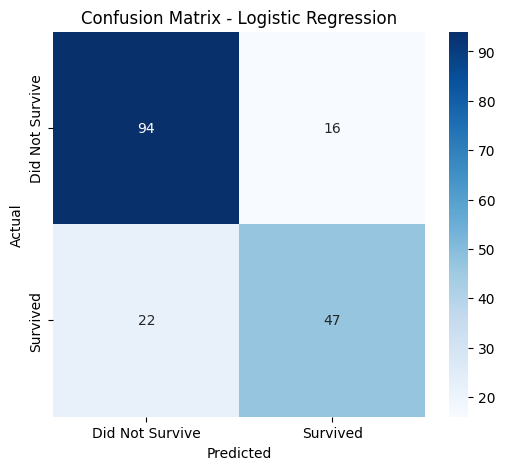

In [4]:
cm = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Did Not Survive", "Survived"],
            yticklabels=["Did Not Survive", "Survived"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()